# Part 2 | Session 10: MoE (Mixture of Experts) 아키텍처와 DeepSeek

**© Copyright AIDENTIFY. All rights reserved.**

## 학습 목표

- Dense 모델과 Sparse(MoE) 모델의 차이를 이해한다.
- Gating Network과 Top-K routing의 동작 원리를 파악한다.
- MoE의 학습/추론 효율성 이점을 분석한다.
- DeepSeek-V2/V3의 핵심 기술(Fine-grained Experts, Shared Experts, MLA)을 학습한다.
- PyTorch로 간단한 MoE 구조를 직접 구현한다.

In [1]:
# 💡 setup.sh 실행했으면 이 셀은 건너뛰세요 (참고용 — 본 노트북이 필요로 하는 패키지)
# 필요한 패키지 설치
# !pip install -q torch matplotlib numpy

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


---
## 1️⃣ MoE 개요: Dense vs Sparse 모델

### Dense 모델 vs Sparse (MoE) 모델

| 특성 | Dense 모델 | Sparse (MoE) 모델 |
|------|-----------|-------------------|
| 활성 파라미터 | 전체 파라미터 100% | 일부만 활성 (예: 10~25%) |
| FLOPs per token | 높음 | 낮음 |
| 총 파라미터 수 | = 활성 파라미터 | >> 활성 파라미터 |
| 예시 | GPT-3 (175B) | Mixtral 8x7B (총 47B, 활성 13B) |

### Expert란?

MoE에서 **Expert**는 Transformer 블록 내 **FFN (Feed-Forward Network) 레이어**를 여러 개의 독립적인 서브네트워크로 분할한 것입니다.

- 각 Expert는 동일한 구조(예: 2-layer MLP)를 가지지만, **서로 다른 가중치**를 학습
- 입력 토큰마다 **일부 Expert만 선택**하여 활성화 (Sparse Activation)

### Gating Network (Router)

**Gating Network**은 각 토큰이 어떤 Expert로 라우팅될지 결정합니다.

$$G(x) = \text{TopK}(\text{Softmax}(W_g \cdot x))$$

$$y = \sum_{i \in \text{TopK}} G(x)_i \cdot E_i(x)$$

- $W_g$: Gating weight matrix
- $E_i(x)$: i번째 Expert의 출력
- TopK: 가장 높은 확률의 K개 Expert만 선택 (보통 K=1 또는 K=2)

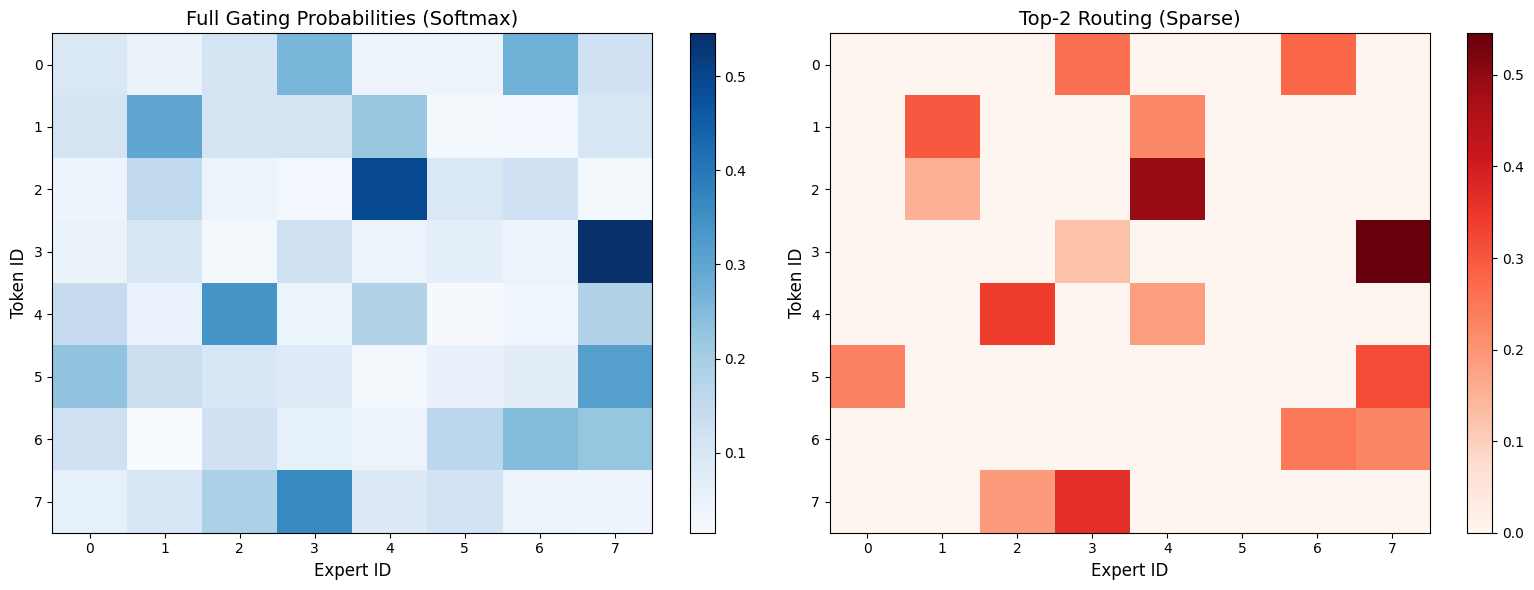

=> 각 토큰은 8개 Expert 중 2개만 활성화합니다.
=> 활성 비율: 2/8 = 25%


In [3]:
# MoE 라우팅 시각화

np.random.seed(42)

num_tokens = 8
num_experts = 8
top_k = 2

# 가상의 gating scores 생성
raw_scores = np.random.randn(num_tokens, num_experts)
gating_probs = np.exp(raw_scores) / np.exp(raw_scores).sum(axis=1, keepdims=True)  # softmax

# Top-K 선택
routing_mask = np.zeros_like(gating_probs)
for i in range(num_tokens):
    top_indices = np.argsort(gating_probs[i])[-top_k:]
    routing_mask[i, top_indices] = gating_probs[i, top_indices]

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 전체 gating probabilities
im1 = axes[0].imshow(gating_probs, cmap='Blues', aspect='auto')
axes[0].set_xlabel('Expert ID', fontsize=12)
axes[0].set_ylabel('Token ID', fontsize=12)
axes[0].set_title('Full Gating Probabilities (Softmax)', fontsize=14)
axes[0].set_xticks(range(num_experts))
axes[0].set_yticks(range(num_tokens))
plt.colorbar(im1, ax=axes[0])

# Top-K routing (sparse)
im2 = axes[1].imshow(routing_mask, cmap='Reds', aspect='auto')
axes[1].set_xlabel('Expert ID', fontsize=12)
axes[1].set_ylabel('Token ID', fontsize=12)
axes[1].set_title(f'Top-{top_k} Routing (Sparse)', fontsize=14)
axes[1].set_xticks(range(num_experts))
axes[1].set_yticks(range(num_tokens))
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"=> 각 토큰은 {num_experts}개 Expert 중 {top_k}개만 활성화합니다.")
print(f"=> 활성 비율: {top_k}/{num_experts} = {top_k/num_experts*100:.0f}%")

---
## 2️⃣ MoE의 장점: 효율성과 성능

### 학습 효율성

- **동일 compute**에서 더 많은 파라미터를 가질 수 있음
- 각 토큰은 일부 Expert만 활성화하므로, FLOPs는 dense 모델과 비슷하지만 총 파라미터(용량)는 훨씬 큼
- 결과적으로 **동일 학습 비용에서 더 낮은 loss** 달성

### 추론 효율성

- 총 파라미터는 많지만, 각 토큰 처리 시 **활성 파라미터만** 연산
- 예: Mixtral 8x7B → 총 47B params이지만, 추론 시 ~13B params만 활성

### 주요 과제 (Challenges)

- **Load Balancing**: 특정 Expert에 토큰이 집중되는 문제 → Auxiliary loss로 해결
- **메모리**: 모든 Expert를 메모리에 올려야 함 → 총 파라미터 크기만큼 메모리 필요
- **통신 비용**: Expert가 여러 GPU에 분산될 때 All-to-All 통신 발생

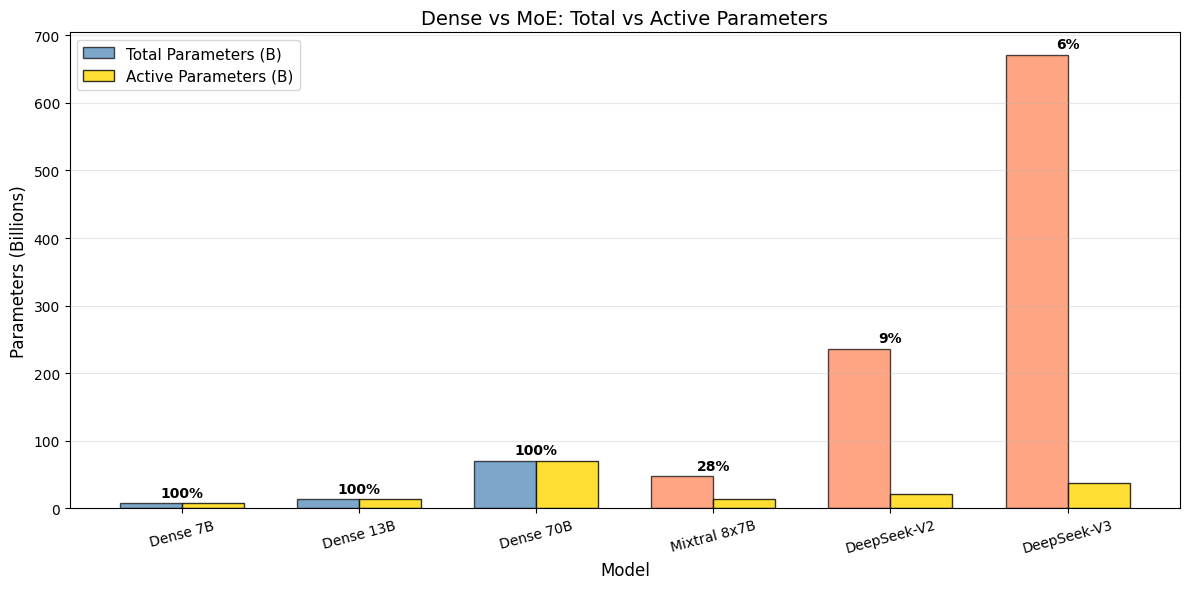

=> MoE 모델은 총 파라미터 대비 활성 파라미터 비율이 매우 낮습니다.
=> DeepSeek-V3: 671B 총 파라미터 중 37B만 활성 (5.5%)


In [4]:
# Dense vs MoE 효율성 비교 시각화

models_comparison = {
    'Dense 7B':     {'total_params': 7,   'active_params': 7,    'type': 'Dense'},
    'Dense 13B':    {'total_params': 13,  'active_params': 13,   'type': 'Dense'},
    'Dense 70B':    {'total_params': 70,  'active_params': 70,   'type': 'Dense'},
    'Mixtral 8x7B': {'total_params': 47,  'active_params': 13,   'type': 'MoE'},
    'DeepSeek-V2':  {'total_params': 236, 'active_params': 21,   'type': 'MoE'},
    'DeepSeek-V3':  {'total_params': 671, 'active_params': 37,   'type': 'MoE'},
}

fig, ax = plt.subplots(figsize=(12, 6))

names = list(models_comparison.keys())
total = [v['total_params'] for v in models_comparison.values()]
active = [v['active_params'] for v in models_comparison.values()]
colors = ['steelblue' if v['type'] == 'Dense' else 'coral' for v in models_comparison.values()]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, total, width, label='Total Parameters (B)', color=colors, alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, active, width, label='Active Parameters (B)', color='gold', alpha=0.8, edgecolor='black')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Parameters (Billions)', fontsize=12)
ax.set_title('Dense vs MoE: Total vs Active Parameters', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 활성 비율 표시
for i, (t, a) in enumerate(zip(total, active)):
    ratio = a / t * 100
    ax.text(i, max(t, a) + 10, f"{ratio:.0f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("=> MoE 모델은 총 파라미터 대비 활성 파라미터 비율이 매우 낮습니다.")
print("=> DeepSeek-V3: 671B 총 파라미터 중 37B만 활성 (5.5%)")

---
## 3️⃣ DeepSeek-V2/V3 아키텍처

DeepSeek은 MoE 아키텍처를 혁신적으로 발전시킨 모델입니다.

### DeepSeekMoE의 핵심 차별점

#### (1) Fine-grained Expert Segmentation

기존 MoE는 Expert 수가 적고(8~16개) 각각이 큰 반면, DeepSeekMoE는:

- Expert를 **더 작고 더 많이** 분할 (예: 160개 routed experts)
- 더 세밀한 지식 분리 가능
- 같은 총 파라미터에서도 더 유연한 조합 가능

#### (2) Shared Expert Isolation

- 일부 Expert를 **공유 Expert (Shared Expert)**로 지정
- 공유 Expert는 **모든 토큰에 대해 항상 활성화**
- 공통 지식(문법, 일반 상식 등)을 공유 Expert가 담당
- Routed Expert는 전문 지식에 집중 가능

```
[기존 MoE]           [DeepSeekMoE]
Token → Router       Token → Router
       ↓                    ↓
   [E1] [E2]           [Shared E] (always active)
   (Top-K)             +
                       [R1] [R2] ... [R160]
                       (Top-K from routed experts)
```

### MLA (Multi-head Latent Attention)

DeepSeek-V2에서 도입된 **MLA**는 KV Cache 크기를 대폭 줄이는 기술입니다.

| 기법 | KV Cache 크기 | 설명 |
|------|-------------|------|
| MHA (Multi-Head Attention) | $2 \times n_h \times d_h \times L$ | 기존 방식, 캐시가 큼 |
| GQA (Grouped Query Attention) | $2 \times n_g \times d_h \times L$ | 그룹으로 묶어 줄임 |
| MQA (Multi-Query Attention) | $2 \times d_h \times L$ | 1개 KV 공유 |
| **MLA** | $d_c \times L$ ($d_c \ll n_h \times d_h$) | 저차원 latent로 압축 |

**MLA의 핵심 아이디어:**
- Key, Value를 저차원 **latent vector** $c^{KV}$로 압축 저장
- 추론 시 $c^{KV}$에서 K, V를 복원
- KV Cache 크기를 GQA 대비 **수 배 이상** 절감

In [5]:
# DeepSeek 모델 스펙 비교

deepseek_models = {
    'DeepSeek-V1 (67B Dense)': {
        'total_params': 67, 'active_params': 67,
        'experts': 'N/A (Dense)', 'attention': 'MHA',
        'training_tokens': '2T'
    },
    'DeepSeek-V2 (236B MoE)': {
        'total_params': 236, 'active_params': 21,
        'experts': '2 shared + 160 routed (Top-6)', 'attention': 'MLA',
        'training_tokens': '8.1T'
    },
    'DeepSeek-V3 (671B MoE)': {
        'total_params': 671, 'active_params': 37,
        'experts': '1 shared + 256 routed (Top-8)', 'attention': 'MLA',
        'training_tokens': '14.8T'
    },
}

print("DeepSeek Model Family Comparison")
print("=" * 90)
print(f"{'Model':<30} {'Total(B)':>10} {'Active(B)':>10} {'Attention':>10} {'Tokens':>10}")
print("-" * 90)
for name, spec in deepseek_models.items():
    print(f"{name:<30} {spec['total_params']:>10} {spec['active_params']:>10} "
          f"{spec['attention']:>10} {spec['training_tokens']:>10}")
print("=" * 90)
print()
for name, spec in deepseek_models.items():
    print(f"{name}")
    print(f"  Experts: {spec['experts']}")
    print()

DeepSeek Model Family Comparison
Model                            Total(B)  Active(B)  Attention     Tokens
------------------------------------------------------------------------------------------
DeepSeek-V1 (67B Dense)                67         67        MHA         2T
DeepSeek-V2 (236B MoE)                236         21        MLA       8.1T
DeepSeek-V3 (671B MoE)                671         37        MLA      14.8T

DeepSeek-V1 (67B Dense)
  Experts: N/A (Dense)

DeepSeek-V2 (236B MoE)
  Experts: 2 shared + 160 routed (Top-6)

DeepSeek-V3 (671B MoE)
  Experts: 1 shared + 256 routed (Top-8)



---
## 4️⃣ 간단한 MoE 구조 PyTorch 구현

아래에서 Top-K Gating과 Expert 라우팅을 포함한 기본적인 MoE 레이어를 구현합니다.

In [6]:
class Expert(nn.Module):
    """단일 Expert: 2-layer MLP (FFN)"""
    def __init__(self, d_model: int, d_ff: int):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.act = nn.SiLU()

    def forward(self, x):
        return self.w2(self.act(self.w1(x)))


class TopKGating(nn.Module):
    """Top-K Gating Network (Router)"""
    def __init__(self, d_model: int, num_experts: int, top_k: int = 2):
        super().__init__()
        self.top_k = top_k
        self.gate = nn.Linear(d_model, num_experts, bias=False)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        logits = self.gate(x)  # (batch, seq_len, num_experts)
        top_k_logits, top_k_indices = torch.topk(logits, self.top_k, dim=-1)
        top_k_weights = F.softmax(top_k_logits, dim=-1)  # 선택된 top-k 안에서만 정규화
        return top_k_weights, top_k_indices, logits


class MoELayer(nn.Module):
    """Mixture of Experts Layer"""
    def __init__(self, d_model: int, d_ff: int, num_experts: int, top_k: int = 2):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.experts = nn.ModuleList([Expert(d_model, d_ff) for _ in range(num_experts)])
        self.gating = TopKGating(d_model, num_experts, top_k)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape

        # Gating: 토큰마다 top-k 전문가와 가중치 결정
        weights, indices, logits = self.gating(x)  # weights/indices: (B, S, K)

        # 토큰을 (B*S, ...) 로 펼쳐서 마스킹/인덱싱을 단순화
        x_flat = x.reshape(-1, d_model)                    # (B*S, d_model)
        weights_flat = weights.reshape(-1, self.top_k)     # (B*S, K)
        indices_flat = indices.reshape(-1, self.top_k)     # (B*S, K)
        output_flat = torch.zeros_like(x_flat)             # (B*S, d_model) — 결과 누적용

        # 같은 전문가를 고른 토큰끼리 묶어 한 번에 처리 (sparse 연산의 핵심)
        for k in range(self.top_k):
            expert_indices = indices_flat[:, k]                 # (B*S,)
            expert_weights = weights_flat[:, k].unsqueeze(-1)   # (B*S, 1)

            for expert_id in range(self.num_experts):
                mask = (expert_indices == expert_id)
                if mask.any():
                    expert_input = x_flat[mask]
                    expert_output = self.experts[expert_id](expert_input)
                    output_flat[mask] += expert_weights[mask] * expert_output

        output = output_flat.reshape(batch_size, seq_len, d_model)

        # Load balancing loss 계산
        balance_loss = self._compute_balance_loss(logits)

        return output, balance_loss

    def _compute_balance_loss(self, logits):
        """Auxiliary balance loss: Expert 사용량을 균등하게 만드는 손실"""
        probs = F.softmax(logits, dim=-1)  # (B, S, E)
        # 각 Expert의 평균 확률
        avg_probs = probs.mean(dim=[0, 1])  # (E,)
        # 각 Expert가 Top-1으로 선택된 비율
        top1 = torch.argmax(logits, dim=-1)  # (B, S)
        freq = torch.zeros(self.num_experts, device=logits.device)
        for i in range(self.num_experts):
            freq[i] = (top1 == i).float().mean()
        # Balance loss = num_experts * dot(freq, avg_probs)
        balance_loss = self.num_experts * (freq * avg_probs).sum()
        return balance_loss


print("MoE 클래스 정의 완료!")

MoE 클래스 정의 완료!


In [7]:
# MoE Layer 테스트

d_model = 256
d_ff = 512
num_experts = 8
top_k = 2

moe_layer = MoELayer(d_model, d_ff, num_experts, top_k)

# 가상 입력
batch_size = 2
seq_len = 16
x = torch.randn(batch_size, seq_len, d_model)

# Forward pass
output, balance_loss = moe_layer(x)

print(f"입력 shape: {x.shape}")
print(f"출력 shape: {output.shape}")
print(f"Balance loss: {balance_loss.item():.4f}")
print()

# 파라미터 수 비교
moe_params = sum(p.numel() for p in moe_layer.parameters())

# 동일 크기의 Dense FFN
dense_ffn = nn.Sequential(
    nn.Linear(d_model, d_ff),
    nn.SiLU(),
    nn.Linear(d_ff, d_model)
)
dense_params = sum(p.numel() for p in dense_ffn.parameters())

print(f"[파라미터 비교]")
print(f"Dense FFN: {dense_params:,} params")
print(f"MoE Layer ({num_experts} experts, top-{top_k}): {moe_params:,} params")
print(f"MoE / Dense 파라미터 비율: {moe_params/dense_params:.1f}x")
print(f"MoE 활성 파라미터 비율: {top_k}/{num_experts} = {top_k/num_experts*100:.0f}%")

입력 shape: torch.Size([2, 16, 256])
출력 shape: torch.Size([2, 16, 256])
Balance loss: 1.0238

[파라미터 비교]
Dense FFN: 262,912 params
MoE Layer (8 experts, top-2): 2,105,344 params
MoE / Dense 파라미터 비율: 8.0x
MoE 활성 파라미터 비율: 2/8 = 25%


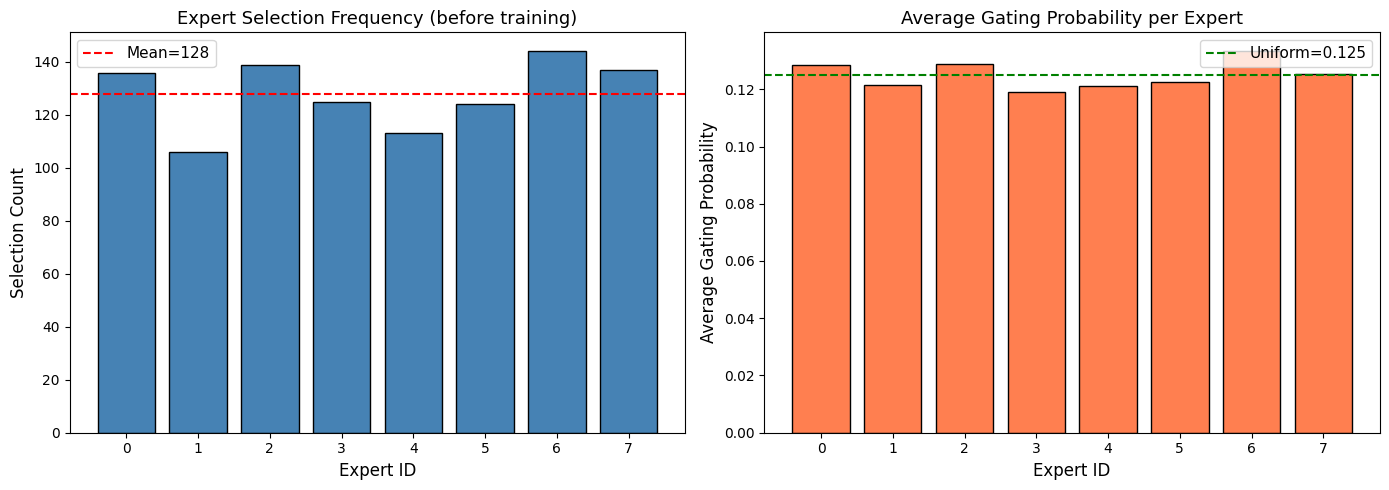

=> 학습 전에는 라우팅이 불균형할 수 있습니다.
=> Balance loss를 통해 학습하면 Expert 사용량이 균등해집니다.


In [8]:
# Expert 라우팅 분포 시각화

# 더 큰 배치로 라우팅 분포 확인
x_test = torch.randn(8, 64, d_model)  # 8 batches, 64 tokens each
with torch.no_grad():
    weights, indices, logits = moe_layer.gating(x_test)

# 각 Expert가 선택된 횟수
all_indices = indices.reshape(-1).numpy()
expert_counts = np.bincount(all_indices, minlength=num_experts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Expert 선택 빈도
axes[0].bar(range(num_experts), expert_counts, color='steelblue', edgecolor='black')
axes[0].axhline(y=expert_counts.mean(), color='red', linestyle='--', label=f'Mean={expert_counts.mean():.0f}')
axes[0].set_xlabel('Expert ID', fontsize=12)
axes[0].set_ylabel('Selection Count', fontsize=12)
axes[0].set_title('Expert Selection Frequency (before training)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xticks(range(num_experts))

# Gating probability 분포
probs = F.softmax(logits, dim=-1).mean(dim=[0, 1]).detach().numpy()
axes[1].bar(range(num_experts), probs, color='coral', edgecolor='black')
axes[1].axhline(y=1.0/num_experts, color='green', linestyle='--', label=f'Uniform={1/num_experts:.3f}')
axes[1].set_xlabel('Expert ID', fontsize=12)
axes[1].set_ylabel('Average Gating Probability', fontsize=12)
axes[1].set_title('Average Gating Probability per Expert', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].set_xticks(range(num_experts))

plt.tight_layout()
plt.show()

print("=> 학습 전에는 라우팅이 불균형할 수 있습니다.")
print("=> Balance loss를 통해 학습하면 Expert 사용량이 균등해집니다.")

In [9]:
# DeepSeekMoE 스타일: Shared Expert + Routed Expert 구현

class DeepSeekMoELayer(nn.Module):
    """DeepSeekMoE 스타일 구현: Shared Expert + Fine-grained Routed Experts"""
    def __init__(self, d_model: int, d_ff: int,
                 num_shared_experts: int = 2,
                 num_routed_experts: int = 16,
                 top_k: int = 4):
        super().__init__()
        self.num_shared = num_shared_experts
        self.num_routed = num_routed_experts
        self.top_k = top_k

        # Shared experts (항상 활성)
        self.shared_experts = nn.ModuleList(
            [Expert(d_model, d_ff) for _ in range(num_shared_experts)]
        )

        # Routed experts (Top-K 선택)
        self.routed_experts = nn.ModuleList(
            [Expert(d_model, d_ff) for _ in range(num_routed_experts)]
        )

        # Router for routed experts
        self.router = nn.Linear(d_model, num_routed_experts, bias=False)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape

        # 1. Shared expert 출력 (모든 토큰에 적용)
        shared_output = sum(expert(x) for expert in self.shared_experts)

        # 2. Routed expert 출력
        logits = self.router(x)  # (B, S, num_routed)
        top_k_logits, top_k_indices = torch.topk(logits, self.top_k, dim=-1)
        top_k_weights = F.softmax(top_k_logits, dim=-1)

        x_flat = x.reshape(-1, d_model)
        routed_output_flat = torch.zeros_like(x_flat)
        indices_flat = top_k_indices.reshape(-1, self.top_k)
        weights_flat = top_k_weights.reshape(-1, self.top_k)

        for k in range(self.top_k):
            for eid in range(self.num_routed):
                mask = (indices_flat[:, k] == eid)
                if mask.any():
                    out = self.routed_experts[eid](x_flat[mask])
                    routed_output_flat[mask] += weights_flat[:, k][mask].unsqueeze(-1) * out

        routed_output = routed_output_flat.reshape(batch_size, seq_len, d_model)

        # 3. Shared + Routed 결합
        return shared_output + routed_output


# 테스트
ds_moe = DeepSeekMoELayer(
    d_model=256, d_ff=512,
    num_shared_experts=2, num_routed_experts=16, top_k=4
)

x_test = torch.randn(2, 16, 256)
output = ds_moe(x_test)

total_params = sum(p.numel() for p in ds_moe.parameters())
shared_params = sum(p.numel() for p in ds_moe.shared_experts.parameters())
routed_params = sum(p.numel() for p in ds_moe.routed_experts.parameters())

print(f"[DeepSeekMoE Layer]")
print(f"  Input: {x_test.shape} -> Output: {output.shape}")
print(f"  Shared experts: {ds_moe.num_shared} (always active)")
print(f"  Routed experts: {ds_moe.num_routed} (Top-{ds_moe.top_k} selected)")
print(f"  Total params: {total_params:,}")
print(f"    Shared: {shared_params:,}")
print(f"    Routed: {routed_params:,}")
print(f"    Router: {total_params - shared_params - routed_params:,}")
print(f"  Active params per token: shared({shared_params:,}) + {ds_moe.top_k}/{ds_moe.num_routed} routed")

[DeepSeekMoE Layer]
  Input: torch.Size([2, 16, 256]) -> Output: torch.Size([2, 16, 256])
  Shared experts: 2 (always active)
  Routed experts: 16 (Top-4 selected)
  Total params: 4,736,512
    Shared: 525,824
    Routed: 4,206,592
    Router: 4,096
  Active params per token: shared(525,824) + 4/16 routed


---
## 5️⃣ DeepSeek 모델 활용 실습 (무료 로컬 실행)

DeepSeek 모델을 직접 사용해 봅니다. 사용 경로는 두 가지입니다.

- **방법 1: DeepSeek API** — DeepSeek-V3(671B) 등 대형 모델을 클라우드로 호출. **유료(선불 충전 필요)** 라 본 실습에서는 **생략**합니다. (아래 셀에 참고 코드만)
- **방법 2: HuggingFace 로컬 실행 (← 우리가 할 것)** — 소형 DeepSeek 모델을 내 GPU에 받아 **무료**로 실행.

> 💡 671B/236B 같은 대형 MoE는 8GB GPU에 올릴 수 없습니다(전체 파라미터를 모두 VRAM에 적재해야 함 — cell 6의 '메모리' 과제). 그래서 로컬 데모는 **소형 DeepSeek 모델**을 사용합니다.

In [10]:
# 💡 setup.sh 실행했으면 이 셀은 건너뛰세요 (참고용 — 로컬 실행에 필요한 패키지)
# !pip install -q transformers accelerate torch

In [11]:
# ℹ️ DeepSeek API 는 유료(선불 충전 필요)라 본 실습에서는 생략합니다.
#    아래 '방법 2: HuggingFace 로컬 실행'(무료)으로 진행하세요.
#
# 참고용 — 키가 있다면 OpenAI 호환 인터페이스로 호출 가능:
#
#   from openai import OpenAI
#   client = OpenAI(api_key="sk-...", base_url="https://api.deepseek.com")
#   resp = client.chat.completions.create(
#       model="deepseek-chat",                       # DeepSeek-V3
#       messages=[{"role": "user", "content": "MoE 아키텍처의 장점 3가지?"}],
#   )
#   print(resp.choices[0].message.content)
#
#   키 발급: https://platform.deepseek.com/  →  API keys  →  Billing 에서 충전 후 사용

print("ℹ️ DeepSeek API(유료)는 생략합니다. 아래 무료 HuggingFace 로컬 실행으로 진행하세요.")

ℹ️ DeepSeek API(유료)는 생략합니다. 아래 무료 HuggingFace 로컬 실행으로 진행하세요.


### 방법 2: HuggingFace Transformers (로컬 실행, 무료)

소형 DeepSeek 모델을 HuggingFace에서 받아 로컬 GPU에서 실행합니다.

- **사용 모델**: `deepseek-ai/deepseek-coder-1.3b-instruct` (DeepSeek 계열, 1.3B)
- **VRAM**: fp16 기준 약 **2.5GB** → RTX 3070(8GB) 등에서 여유롭게 실행 (실측 검증됨)
- **첫 실행**: 가중치 약 2.6GB 다운로드 (이후 캐시되어 재다운로드 없음)

> **모델 선택 기준 (8GB GPU)**
> | 모델 | VRAM | 비고 |
> |------|------|------|
> | deepseek-coder-1.3b-instruct | ~2.5GB (fp16) | ✅ 본 데모 |
> | DeepSeek-V2-Lite (MoE 15.7B) | ~9GB (4bit) | ❌ 8GB 초과 |
> | DeepSeek-V3 (671B) | 수백 GB | ❌ API로만 |

In [12]:
# 🤗 HuggingFace 로컬 실행 데모 (무료) — RTX 3070(8GB)에서 동작 확인
# 모델: deepseek-ai/deepseek-coder-1.3b-instruct
#   - DeepSeek 계열, dense 1.3B, fp16 로 약 2.5GB VRAM → 8GB GPU 에서 여유롭게 실행
#   - (게이트 모델이 아니라 HF 토큰 없이도 다운로드 가능. 첫 실행 시 ~2.6GB 다운로드)
import time, torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "deepseek-ai/deepseek-coder-1.3b-instruct"


def show_vram(tag=""):
    if torch.cuda.is_available():
        free, total = torch.cuda.mem_get_info()
        print(f"  [{tag}] VRAM 여유 {free/1024**3:.1f} / {total/1024**3:.1f} GB")


if not torch.cuda.is_available():
    print("⚠ CUDA GPU가 없습니다 — CPU로도 동작하지만 느립니다.")

print(f"📥 모델 로딩: {MODEL_NAME}")
show_vram("로딩 전")

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:                  # 생성 경고 방지
    tokenizer.pad_token_id = tokenizer.eos_token_id
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,                            # transformers 4.5x: torch_dtype → dtype
    device_map="auto",
)
print(f"  ✅ 로딩 완료 ({time.time() - t0:.1f}s)")
show_vram("로딩 후")

# 추론 (chat 템플릿 적용 + attention_mask 포함)
messages = [{"role": "user", "content": "파이썬으로 1부터 n까지의 합을 구하는 함수를 작성해줘."}]
inputs = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True,
    return_tensors="pt", return_dict=True,
).to(model.device)

t0 = time.time()
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(f"\n💬 응답 ({time.time() - t0:.1f}s):\n{response}")

/home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📥 모델 로딩: deepseek-ai/deepseek-coder-1.3b-instruct
  [로딩 전] VRAM 여유 7.3 / 7.6 GB
  ✅ 로딩 완료 (2.1s)
  [로딩 후] VRAM 여유 4.6 / 7.6 GB

💬 응답 (0.9s):
def sum_to_n(n):
    return sum(range(1, n+1))

print(sum_to_n(10))



---
## 정리

### 핵심 요약

1. **MoE (Mixture of Experts)**는 모델의 일부 파라미터만 활성화하는 Sparse 아키텍처
2. **Gating Network**이 각 토큰을 Top-K Expert로 라우팅하며, Load Balancing Loss로 균형 유지
3. **DeepSeekMoE**의 혁신:
   - Fine-grained experts: 더 작고 많은 Expert로 세밀한 지식 분리
   - Shared experts: 공통 지식을 담당하는 항상 활성 Expert
4. **MLA (Multi-head Latent Attention)**는 KV Cache를 저차원 latent로 압축하여 추론 효율성 극대화
5. DeepSeek-V3는 671B 총 파라미터 중 37B만 활성화하여, Dense 모델 대비 뛰어난 효율성 달성

### 참고 문헌

- Shazeer et al. (2017). "Outrageously Large Neural Networks: The Sparsely-Gated Mixture-of-Experts Layer." [arXiv:1701.06538](https://arxiv.org/abs/1701.06538)
- Jiang et al. (2024). "Mixtral of Experts." [arXiv:2401.04088](https://arxiv.org/abs/2401.04088)
- Dai et al. (2024). "DeepSeekMoE: Towards Ultimate Expert Specialization in Mixture-of-Experts Language Models." [arXiv:2401.06066](https://arxiv.org/abs/2401.06066)
- DeepSeek-AI (2024). "DeepSeek-V2: A Strong, Economical, and Efficient Mixture-of-Experts Language Model." [arXiv:2405.04434](https://arxiv.org/abs/2405.04434)
- DeepSeek-AI (2024). "DeepSeek-V3 Technical Report." [arXiv:2412.19437](https://arxiv.org/abs/2412.19437)